In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import cv2

In [2]:
img = cv2.imread(r"C:\Users\Praveenkumar\OneDrive\Desktop - Copy\Desktop\PROGRAMS\ML\Image class\test\1.jpg")
img.shape

(1042, 1041, 3)

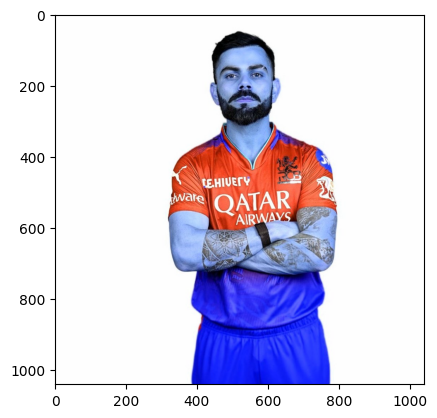

In [3]:
plt.imshow(img)

In [4]:
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

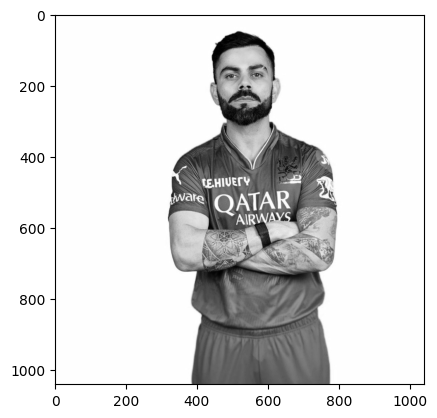

In [5]:
plt.imshow(gray,cmap='gray')

In [6]:
gray.shape

(1042, 1041)

In [7]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")

In [8]:
faces = face_cascade.detectMultiScale(gray,1.1,5)
faces

array([[430,  85, 209, 209]])

In [9]:
x,y,w,h = faces[0]
x,y,w,h

(430, 85, 209, 209)

In [10]:
face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(0,0,255),2)

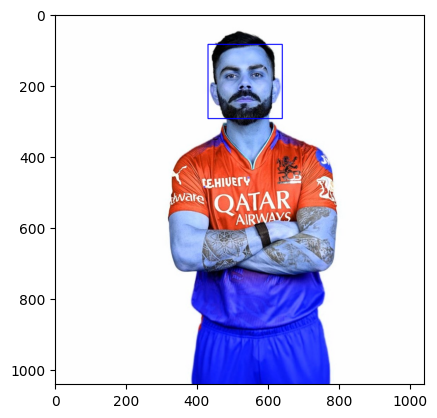

In [11]:
plt.imshow(face_img)

In [12]:
x,y,w,h

(430, 85, 209, 209)

(41, 68, 45, 45)

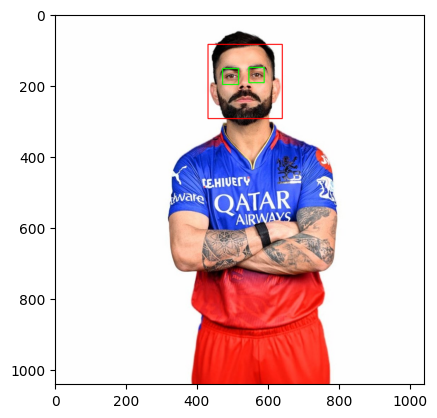

In [13]:
roi_gray = gray[y:y+h, x:x+w]
roi_color = face_img[y:y+h, x:x+w]
eyes = eye_cascade.detectMultiScale(roi_gray)
for (ex,ey,ew,eh) in eyes:
    cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(0,255,0),2)
plt.imshow(cv2.cvtColor(face_img, cv2.COLOR_BGR2RGB))
ex,ey,ew,eh

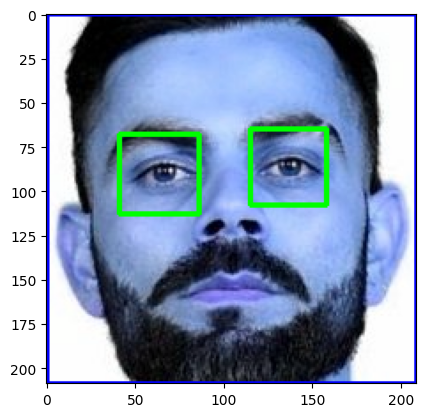

In [14]:
plt.imshow(roi_color)

In [15]:
def cropped_imges(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray,1.1,5)
    for (x,y,w,h) in faces:
        roi_gray = gray[y:y+h,x:x+w]
        roi_color = img[y:y+h,x:x+w]
        eyes = eye_cascade.detectMultiScale(roi_gray)
        if len(eyes) >=2:
            return roi_color

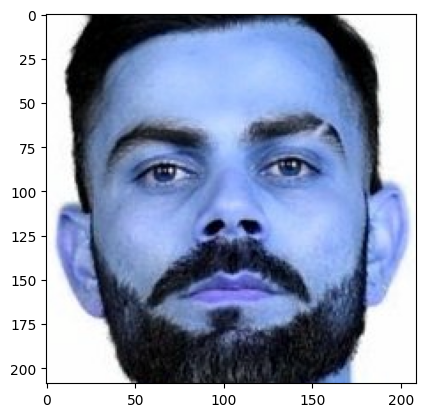

In [16]:
crop_img = cropped_imges(r"C:\Users\Praveenkumar\OneDrive\Desktop - Copy\Desktop\PROGRAMS\ML\Image class\Test\1.jpg")
plt.imshow(crop_img)

In [17]:
import os
path_to_data = r"C:\Users\Praveenkumar\OneDrive\Desktop - Copy\Desktop\PROGRAMS\ML\Image class\Image set"
path_to_cr_data = r"C:\Users\Praveenkumar\OneDrive\Desktop - Copy\Desktop\PROGRAMS\ML\Image class\Croped set"
img_dir = [i.path for i in os.scandir(path_to_data) if i.is_dir()]

In [18]:
cropped_image_dirs = []
celebrity_file_names_dict = {}
for img_directory in img_dir:
    count = 1
    celebrity_name = os.path.basename(img_directory)
    print("Processing:", celebrity_name)
    celebrity_file_names_dict[celebrity_name] = []
    for entry in os.scandir(img_directory):
        if entry.is_file():
            roi_color = cropped_imges(entry.path)
            if roi_color is not None:
                cropped_folder = os.path.join(path_to_cr_data, celebrity_name)        
                if not os.path.exists(cropped_folder):
                    os.makedirs(cropped_folder)
                    cropped_image_dirs.append(cropped_folder)
                    print("Generating cropped images in folder:", cropped_folder)
                cropped_file_name = celebrity_name + str(count) + ".png"       
                cropped_file_path = os.path.join(cropped_folder, cropped_file_name)         
                cv2.imwrite(cropped_file_path, roi_color)
                celebrity_file_names_dict[celebrity_name].append(cropped_file_path)
                count += 1
print("Cropping completed")

Processing: lionel_messi
Processing: maria_sharapova
Processing: roger_federer
Processing: serena_williams
Processing: virat_kohli
Cropping completed


In [19]:
import numpy as np
import pywt
import cv2

def w2d(img, mode='haar', level=1):
    imArray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    imArray = np.float32(imArray)
    imArray /= 255
    coeffs = pywt.wavedec2(imArray, mode, level=level)
    coeffs_H = list(coeffs)
    coeffs_H[0] *= 0
    imArray_H = pywt.waverec2(coeffs_H, mode)
    imArray_H *= 255
    imArray_H = np.uint8(imArray_H)
    
    return imArray_H

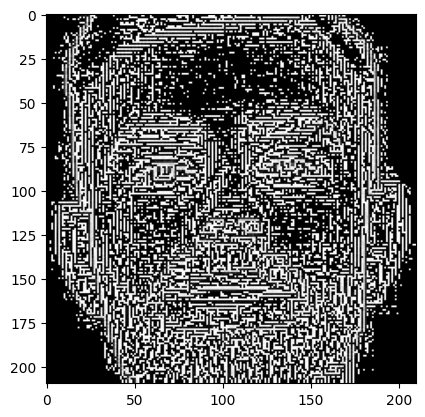

In [ ]:
im_har = w2d(crop_img,'haar',1)
plt.imshow(np.abs(im_har), cmap = 'gray')

In [21]:
class_dict = {}
c = 0
for cel_name in celebrity_file_names_dict.keys():
    class_dict[cel_name] = c
    c=c+1
class_dict

{'lionel_messi': 0,
 'maria_sharapova': 1,
 'roger_federer': 2,
 'serena_williams': 3,
 'virat_kohli': 4}

In [22]:
x,y = [],[]
for cel_name,train_files in celebrity_file_names_dict.items():
    for train_img in train_files:
        img = cv2.imread(train_img)
        if img is None:
            continue
        scalled_raw_img = cv2.resize(img,(32,32))
        img_har = w2d(img,'db1',5)
        scalled_img_har = cv2.resize(img_har,(32,32))
        combined_img  = np.vstack((scalled_raw_img.reshape(32*32*3,1),scalled_img_har.reshape(-1,1)))
        x.append(combined_img)
        y.append(class_dict[cel_name])

In [23]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [24]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2,random_state=42)
xtrain = np.array(xtrain)
xtest = np.array(xtest)

In [25]:
from sklearn.preprocessing import FunctionTransformer
import numpy as np

flatten = FunctionTransformer(lambda x: x.reshape(x.shape[0], -1))

pipe = Pipeline([
    ('flatten', flatten),
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', C=10))
])

In [26]:
pipe.fit(xtrain,ytrain)

,steps,"[('flatten', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function <la...002548926D260>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


In [27]:
pipe.score(xtest,ytest)

0.9523809523809523

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [29]:
model_params = {
        'svm':{'model': SVC(probability=True),'params' : {'svc__C':[1,10,20],'svc__kernel':['rbf','linear'],'svc__gamma': ['scale', 0.01, 0.001]}},
        'randomforest':{'model': RandomForestClassifier(),'params' : {'randomforestclassifier__n_estimators':[1,10,20]}},
        'logreg':{'model': LogisticRegression(),'params' : {'logisticregression__C': [1, 10, 20]}}
}

In [30]:
scores = []
best_estimators = {}

import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import FunctionTransformer

def flatten_images(x):
    return x.reshape(x.shape[0], -1)
flatten = FunctionTransformer(flatten_images)

for algo, mp in model_params.items():
    
    pipe = make_pipeline(flatten,StandardScaler(), mp['model'])
    
    clf = GridSearchCV(
        pipe,
        mp['params'],
        cv=5,
        return_train_score=False
    )
    
    clf.fit(xtrain, ytrain)
    
    scores.append({
        'model': algo,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })
    
    best_estimators[algo] = clf.best_estimator_

df = pd.DataFrame(scores, columns=['model', 'best_score', 'best_params'])
df

,model,best_score,best_params
0,svm,0.743137,"{'svc__C': 1, 'svc__gamma': 'scale', 'svc__ker..."
1,randomforest,0.611230,{'randomforestclassifier__n_estimators': 20}
2,logreg,0.731194,{'logisticregression__C': 1}


In [31]:
best_estimators['svm'].score(xtest,ytest)

0.8809523809523809

In [32]:
best_estimators['randomforest'].score(xtest,ytest)

0.7380952380952381

In [33]:
best_estimators['logreg'].score(xtest,ytest)

0.9285714285714286

In [34]:
best_clf = best_estimators['svm']

In [35]:
import joblib
joblib.dump(best_clf,'saved_model.pkl')

['saved_model.pkl']

In [36]:
import json
with open("class_dictionary.json","w") as f:
    f.write(json.dumps(class_dict))